In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv


In [2]:
# General purpose modules import
import time
from copy import deepcopy
import warnings

# Data handling and visualization modules
import numpy as np
np.random.seed(42)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Skikit-learn preprocessing and evaluation modules
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import TargetEncoder, KBinsDiscretizer, StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, accuracy_score

# Skikit-learn ML modules
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_class_weight

# Further ML modules
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
#SHAP
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

In [3]:
df = pd.read_csv('/kaggle/input/datasets/alfathterry/telco-customer-churn-11-1-3/telco.csv')

train_df, test_df = train_test_split(df, stratify = df['Churn Label'],test_size = 0.2,  random_state = 1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [5]:
FEATURES = ['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 
            'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude',
            'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months',
            'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 
            'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 
            'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
            'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
            'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
            'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 
            'Satisfaction Score', 'Customer Status', 'Churn Score', 'CLTV', 
            'Churn Category', 'Churn Reason']

TARGET = 'Churn Label'

mappings = {'No': 0, 'Yes': 1}
reverse_mappings = {0 : 'No', 1: 'Yes'}

train_df['Churn Label'] = train_df['Churn Label'].map(mappings)
test_df['Churn Label'] = test_df['Churn Label'].map(mappings)

train_df = train_df.drop('Customer ID',axis = 1, errors = 'ignore')
test_df = test_df.drop('Customer ID', axis = 1 , errors = 'ignore')

train_df['Offer'] = train_df['Offer'].fillna('None')
test_df['Offer'] = test_df['Offer'].fillna('None')

train_df['Internet Type'] = train_df['Internet Type'].fillna('No')
test_df['Internet Type'] = test_df['Internet Type'].fillna('No')

train_df['Zip Code'] = train_df['Zip Code'].astype(str)
test_df['Zip Code'] = test_df['Zip Code'].astype(str)

train_df = train_df.drop(['Under 30'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Under 30'], axis = 1 , errors = 'ignore')

train_df = train_df.drop(['Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'], axis = 1 , errors = 'ignore')

train_df = train_df.drop(['Country','State','Quarter'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Country','State','Quarter'], axis = 1 , errors = 'ignore')

train_df = train_df.drop(['Customer Status','Satisfaction Score'], axis = 1, errors = 'ignore')
test_df = test_df.drop(['Customer Status','Satisfaction Score'], axis = 1 , errors = 'ignore')

num_cols = ['Age', 'Number of Dependents', 'Latitude', 'Longitude', 'Population', 
            'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 
            'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 
            'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']

cat_cols = ['Gender', 'Senior Citizen', 'Married', 'Dependents', 'City', 
            'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service',
            'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 
            'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 
            'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method','Zip Code']


<Axes: xlabel='Churn Label', ylabel='Count'>

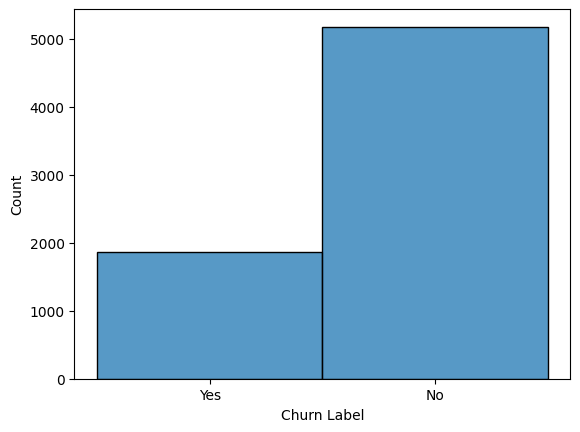

In [6]:
sns.histplot(df[TARGET])

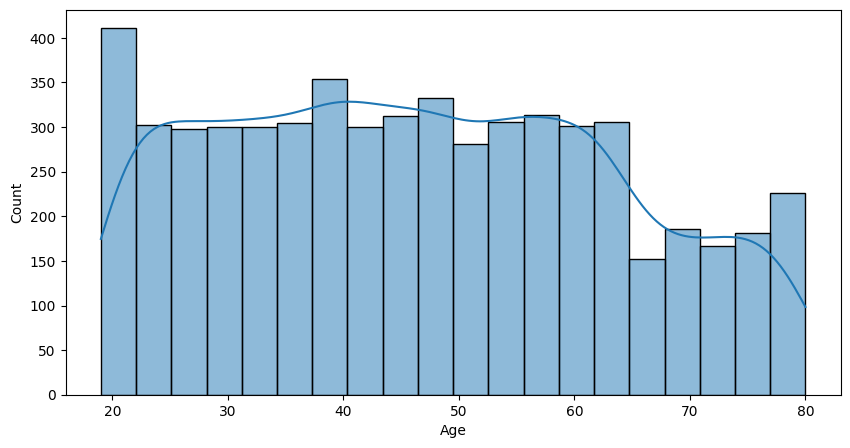

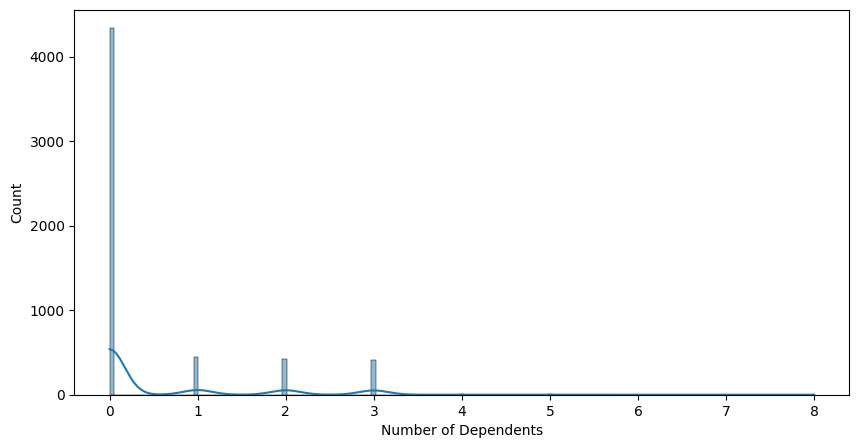

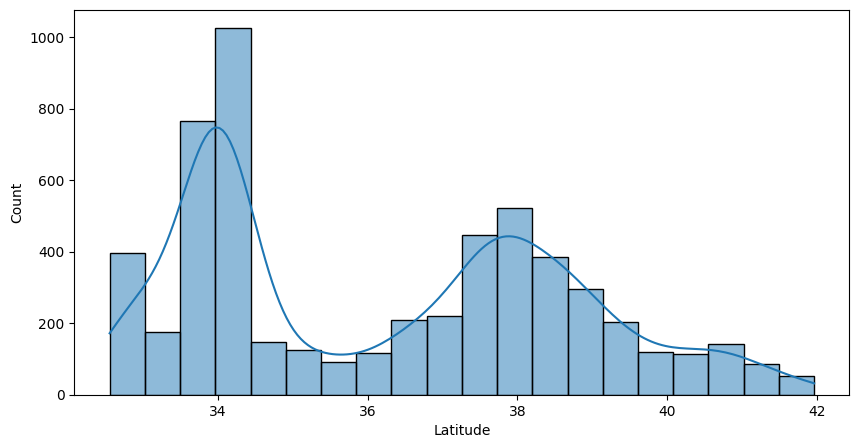

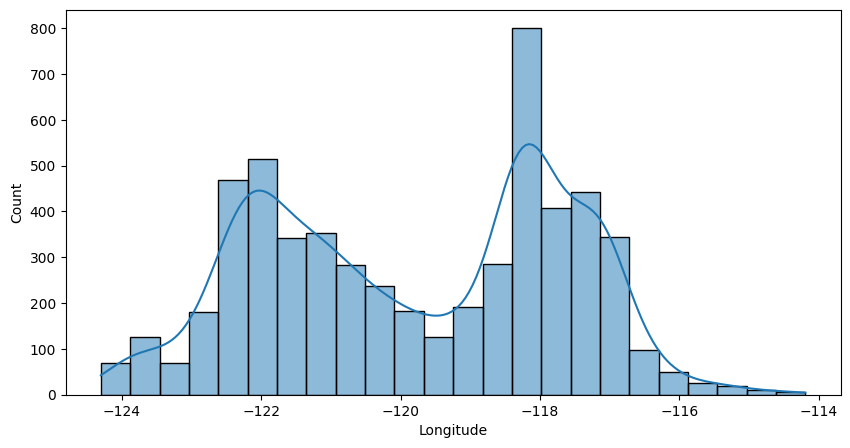

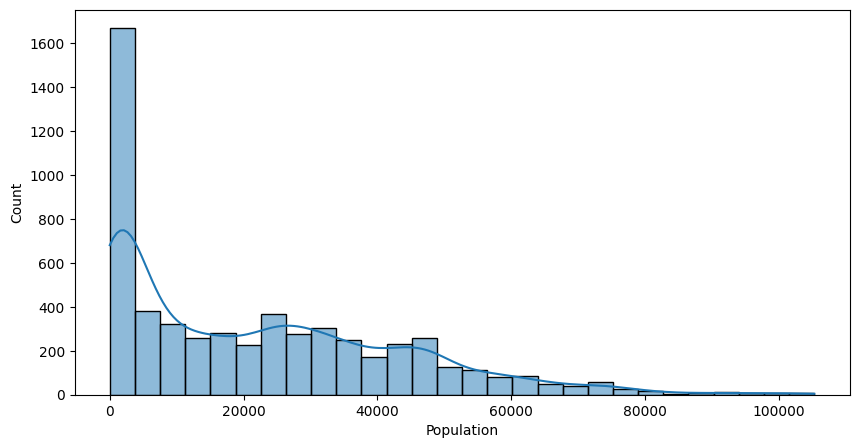

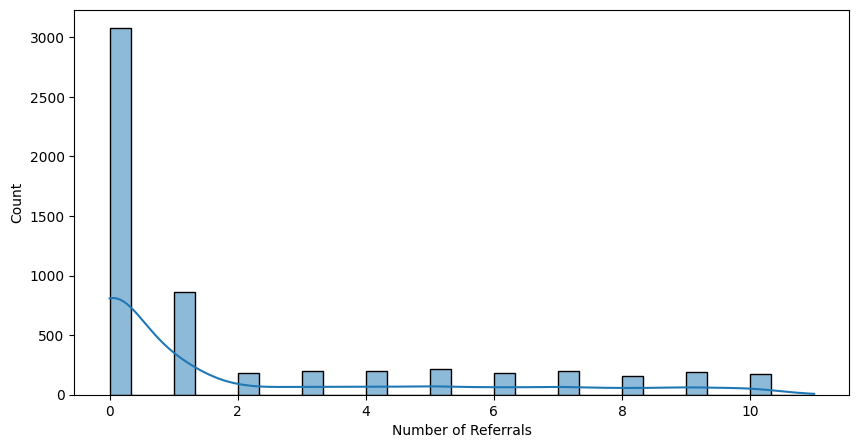

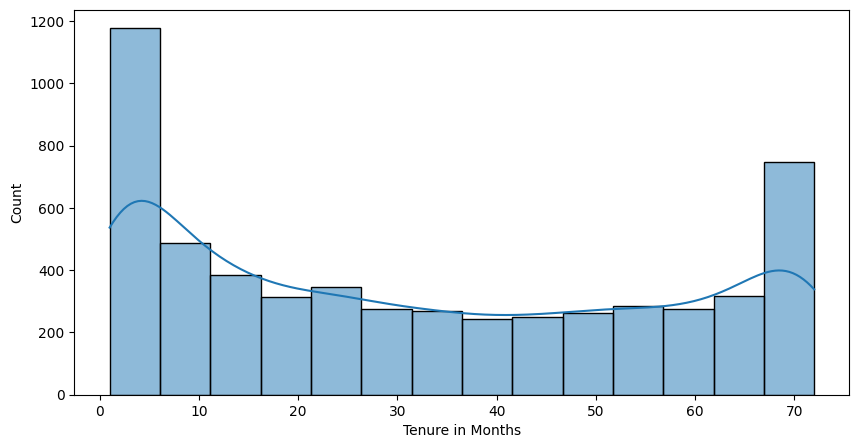

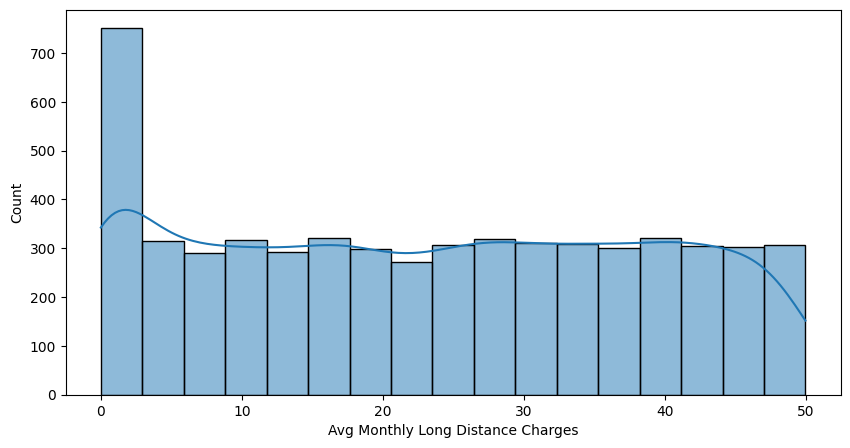

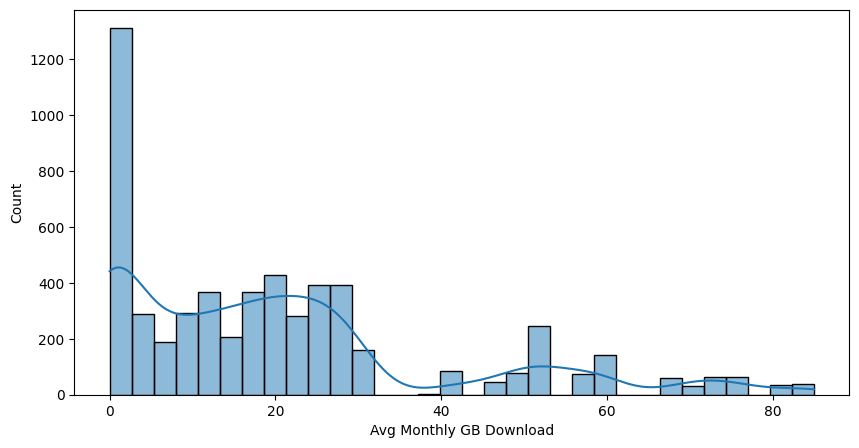

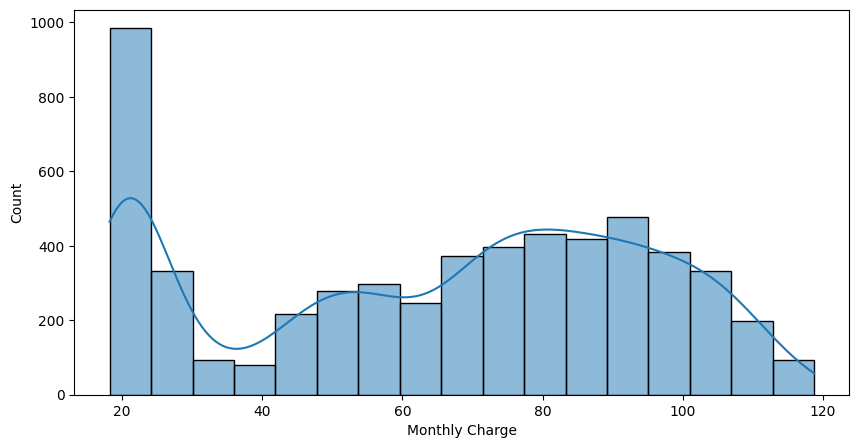

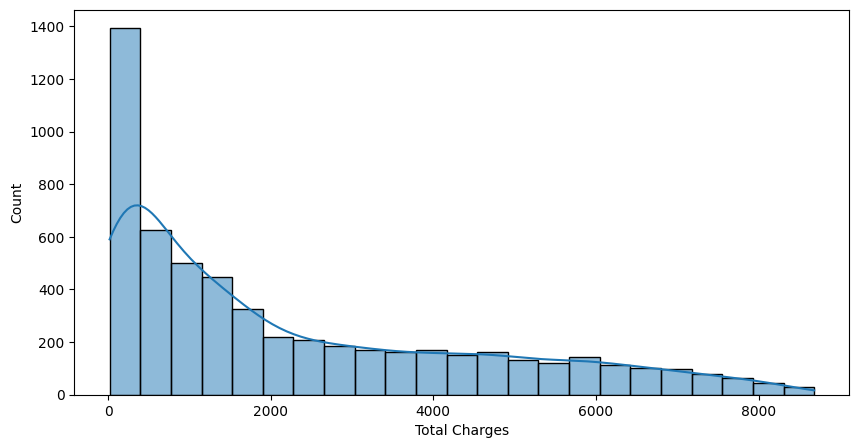

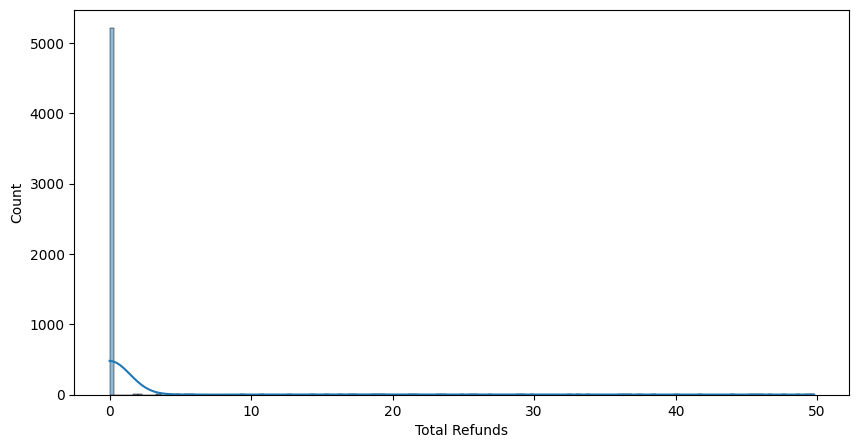

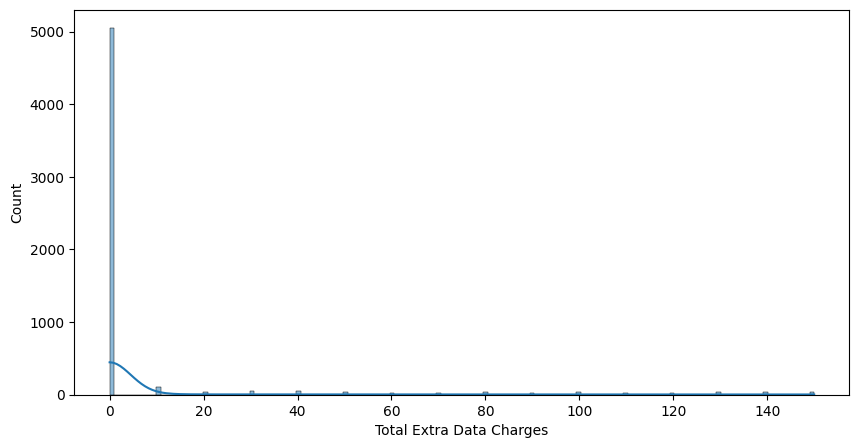

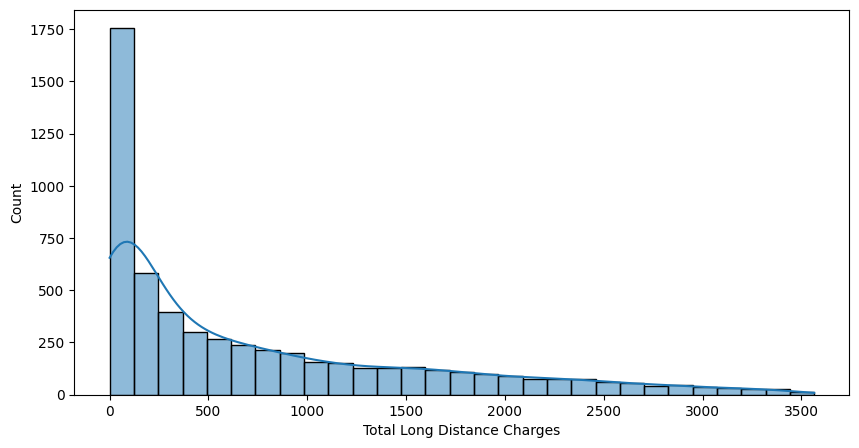

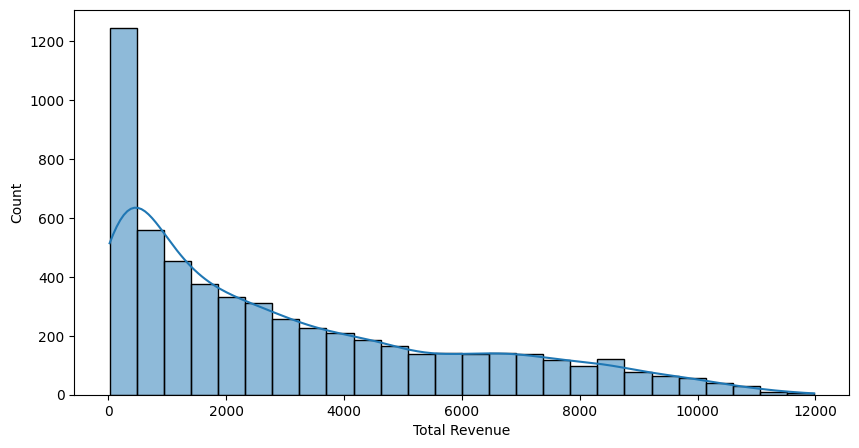

In [7]:
for col in num_cols:
    plt.figure(figsize = (10,5))
    sns.histplot(train_df[col],kde =True)
    plt.plot()

In [8]:
for col in cat_cols:
    print(train_df[col].value_counts())

Gender
Male      2830
Female    2804
Name: count, dtype: int64
Senior Citizen
No     4722
Yes     912
Name: count, dtype: int64
Married
No     2930
Yes    2704
Name: count, dtype: int64
Dependents
No     4339
Yes    1295
Name: count, dtype: int64
City
San Diego        238
Los Angeles      238
Sacramento        92
San Jose          91
San Francisco     85
                ... 
Travis Afb         1
Standish           1
Niland             1
Twain              1
Clayton            1
Name: count, Length: 1105, dtype: int64
Referred a Friend
No     3077
Yes    2557
Name: count, dtype: int64
Offer
None       3108
Offer B     654
Offer E     653
Offer D     488
Offer A     405
Offer C     326
Name: count, dtype: int64
Phone Service
Yes    5100
No      534
Name: count, dtype: int64
Multiple Lines
No     3244
Yes    2390
Name: count, dtype: int64
Internet Service
Yes    4415
No     1219
Name: count, dtype: int64
Internet Type
Fiber Optic    2430
DSL            1298
No             1219
Cable      

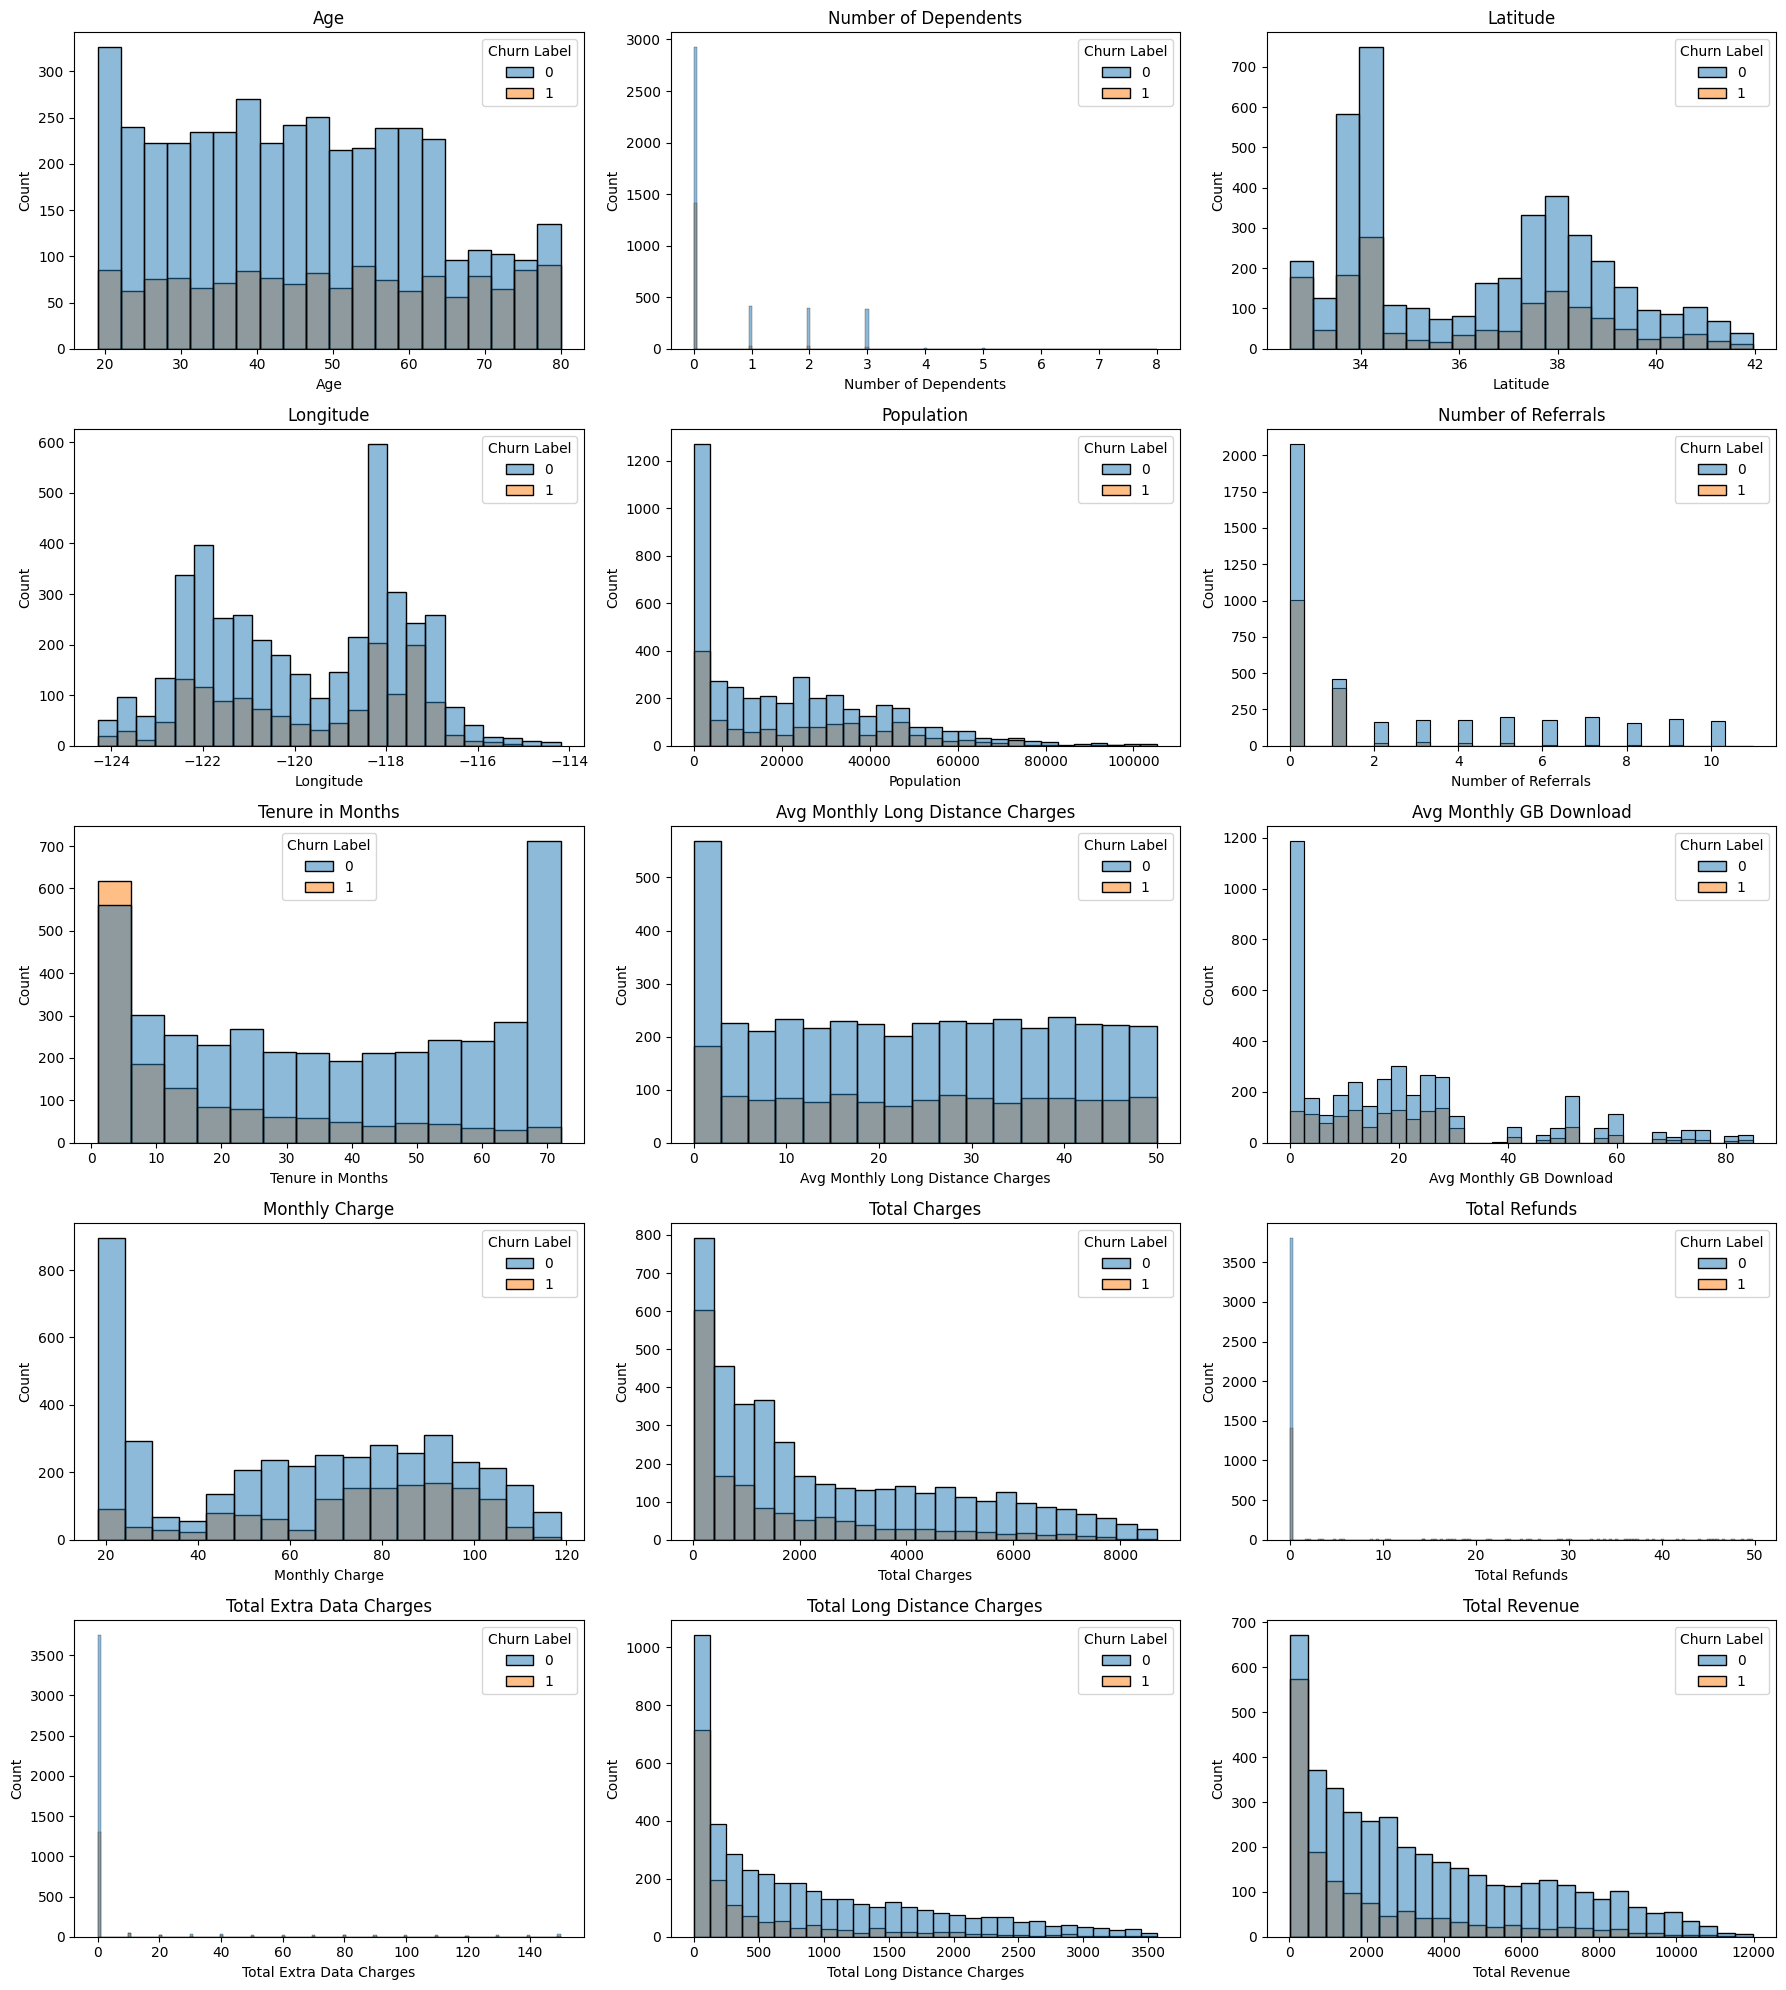

In [9]:

features = num_cols  # list of numeric columns

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=train_df,
        x=feature,
        hue=TARGET,
        ax=axes[i]
    )
    axes[i].set_title(feature)

# Remove unused subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

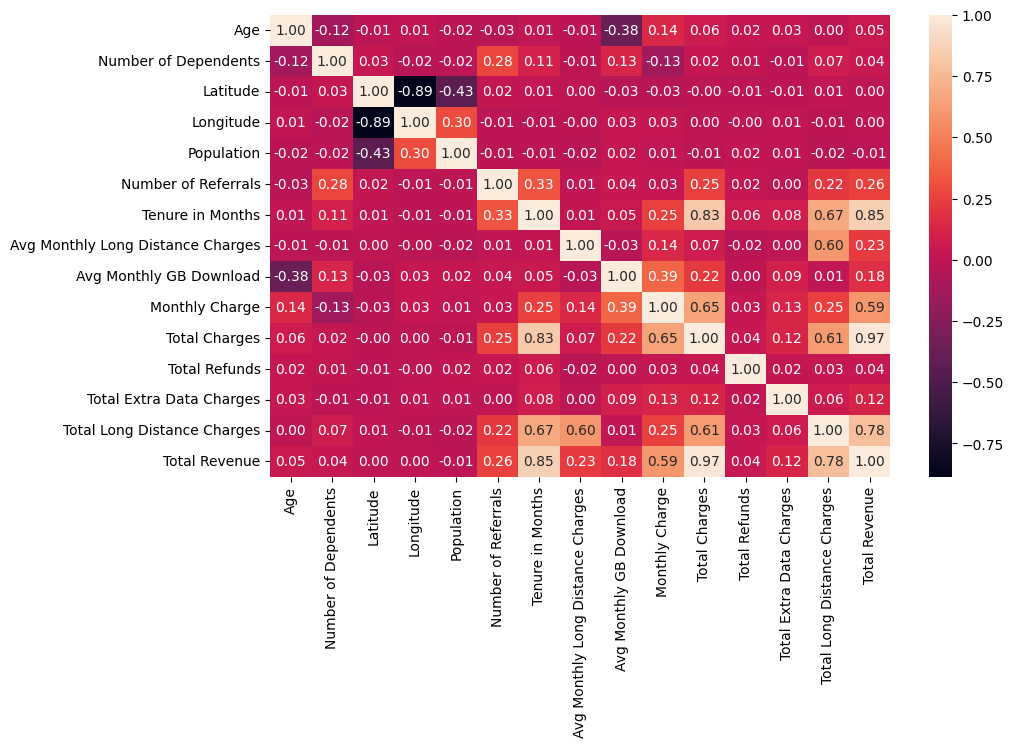

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(),annot=True,fmt=".2f")

plt.show()

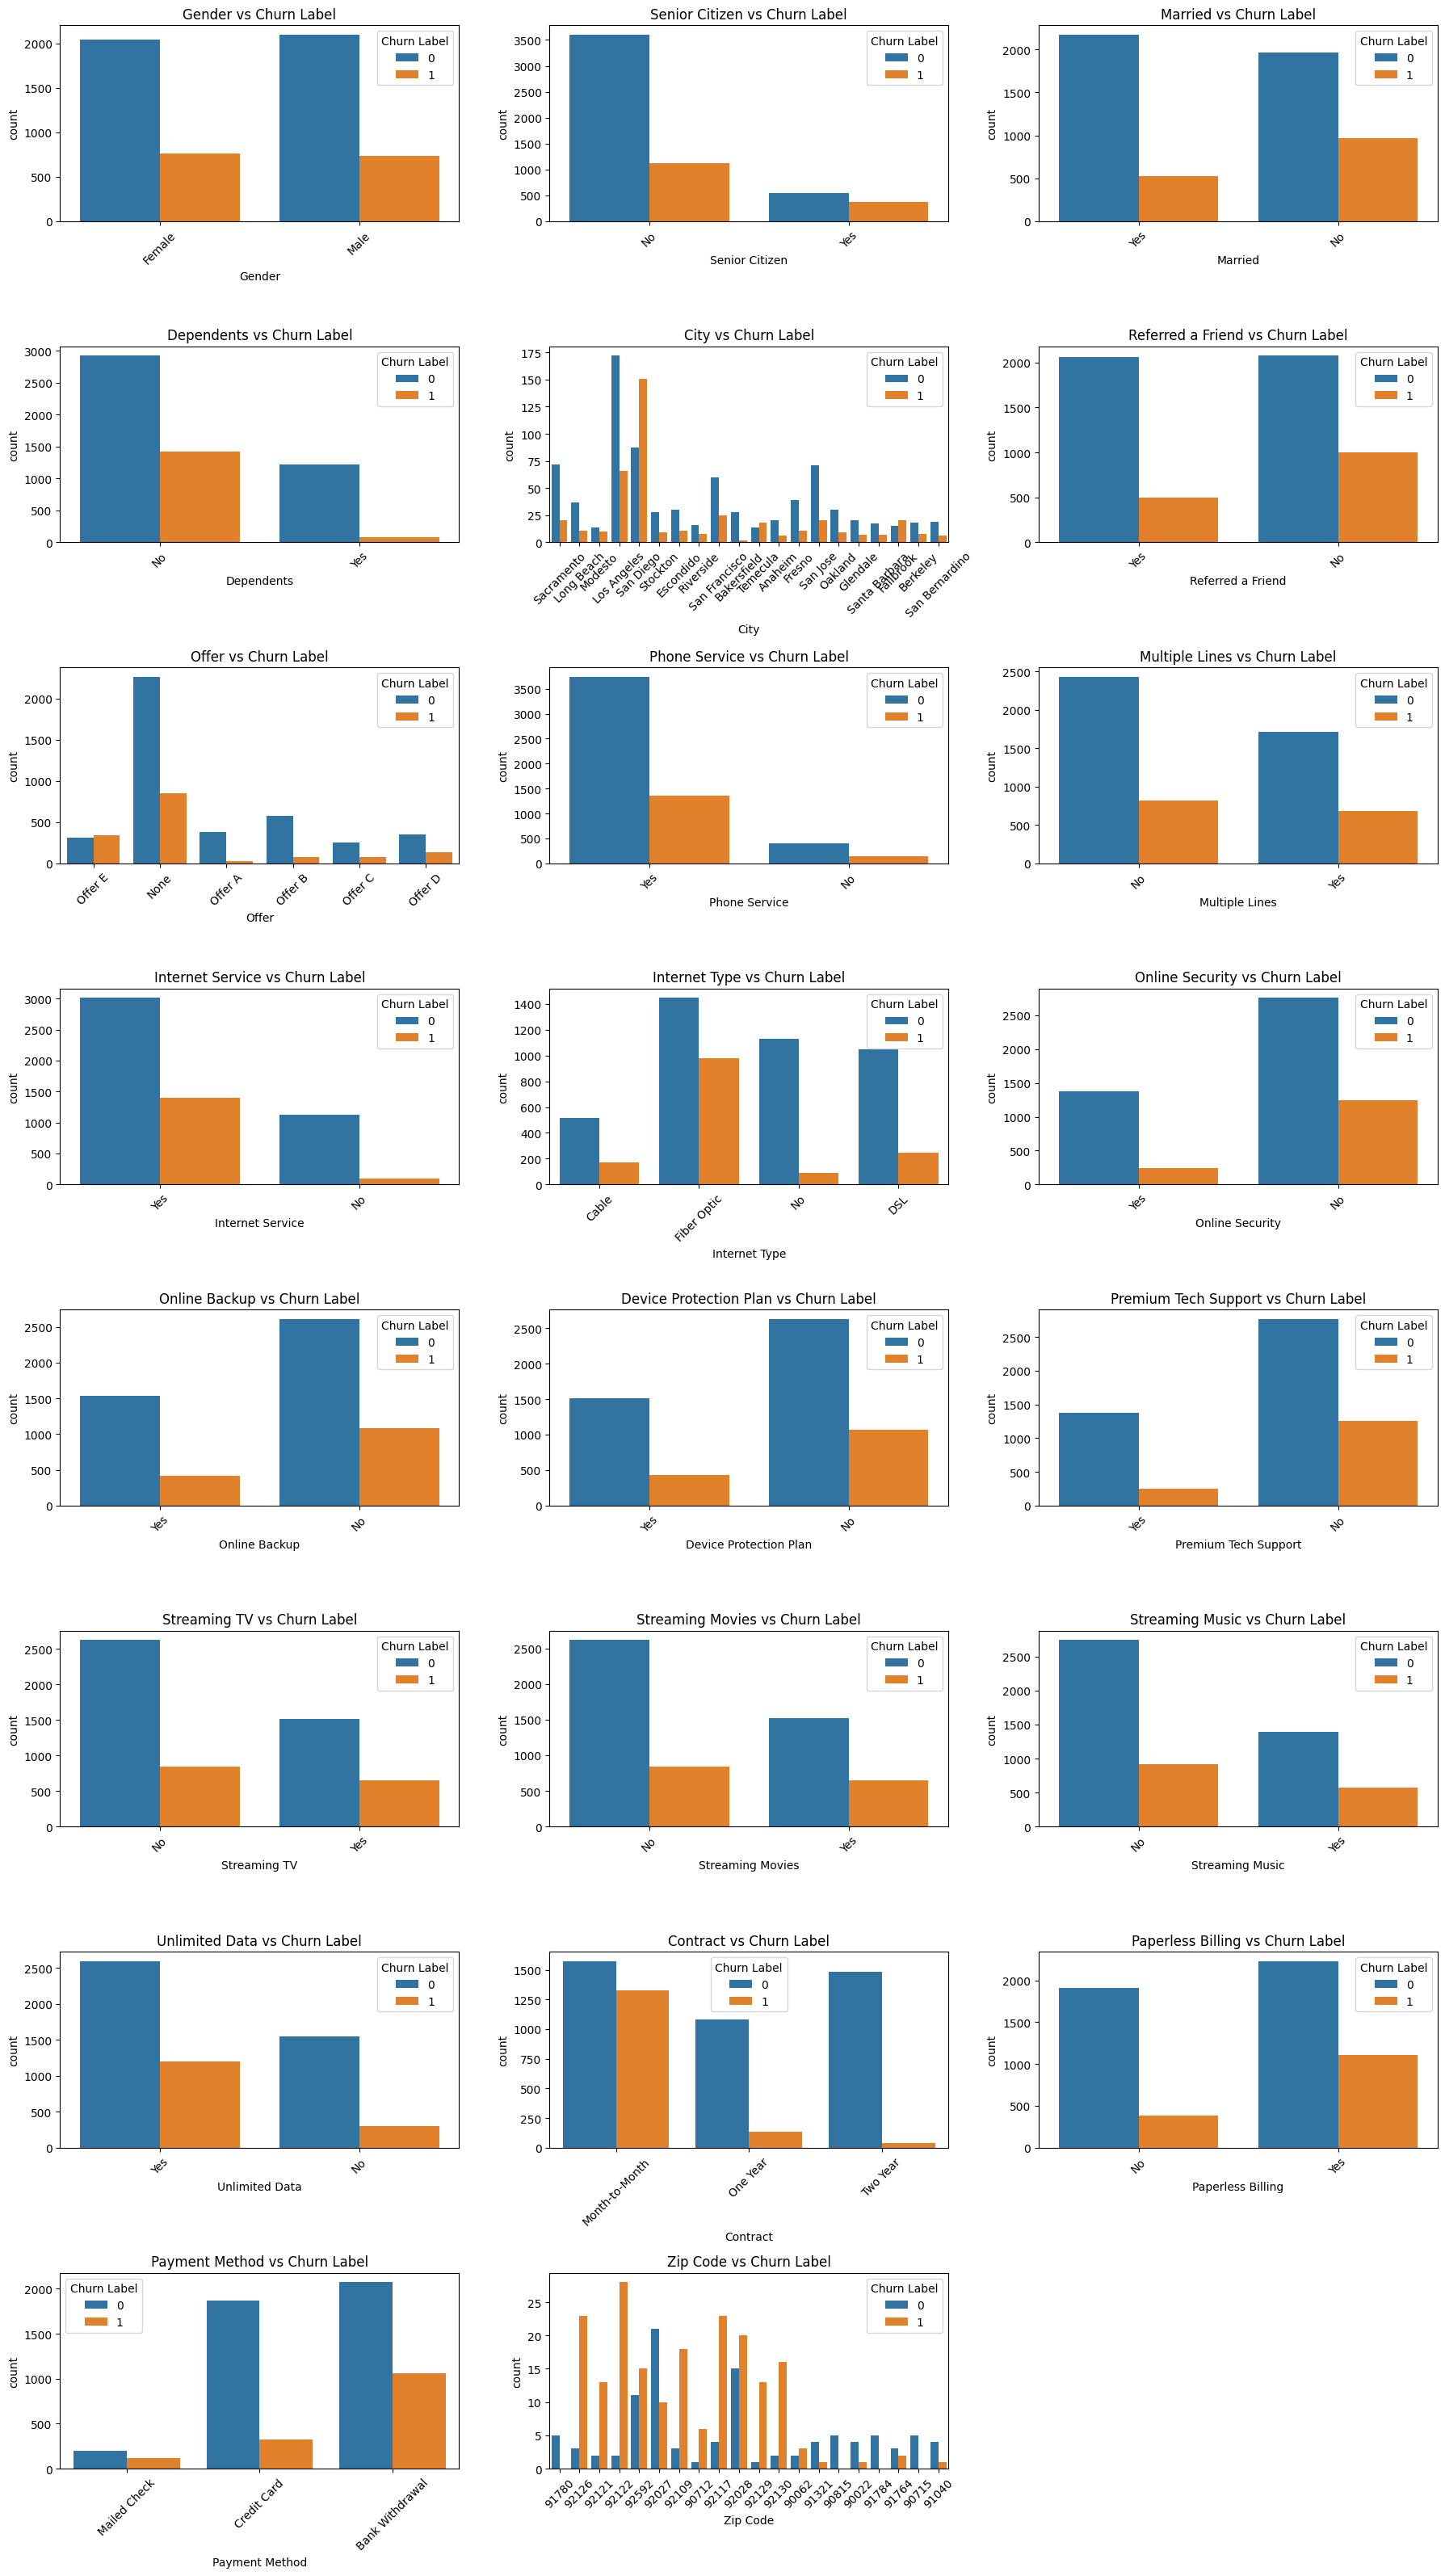

In [11]:
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top20 = train_df[col].value_counts().head(20).index

    sns.countplot(
        data=train_df[train_df[col].isin(top20)],
        x=col,
        hue=TARGET,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs {TARGET}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

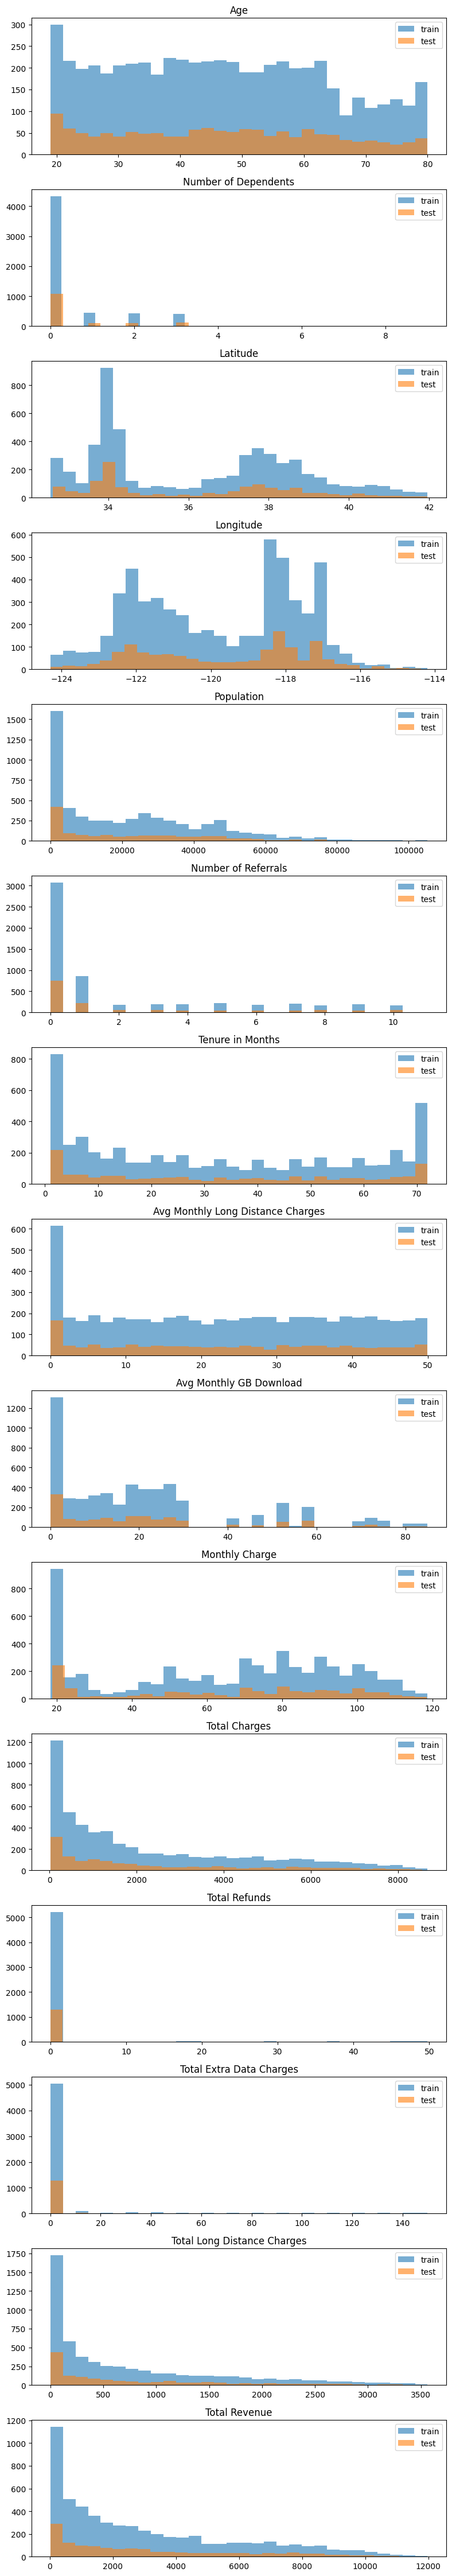

In [12]:
n = len(num_cols)
fig, axes = plt.subplots(n, 1, figsize=(8, 3*n))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    ax.hist(train_df[col], bins=30, alpha=0.6, label='train')
    ax.hist(test_df[col], bins=30, alpha=0.6, label='test')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()
